### Testing script of the CNN model
#### TODO:

+ plot the accuracy of the different epochs and cnns with and without augmentation (you still have the models!)
+ Why Adam and not AdamW? 
+ Create requirments file!

**At the end**
+ Make it all in a script to be run from command line
+ Add argument parsing for hyperparameters


### **Notes to the output and the version meanings**
#### /cnn_trained_models/Ten_epochs and /cnn_training_curves/Ten_epochs
+ _wo_normalization: There we did not normalize the img in Load_Cifar with std and dev
+ v1: without data augmentation

Simple CNN
Total Training Time  : 338.53s
Total Validation Time: 43.40s

SimpleAdaptiveCNN
Total Training Time  : 338.12s
Total Validation Time: 42.64s


+ v2: with data augmentation

Simple CNN
Total Training Time  : 417.16s
Total Validation Time: 50.60s

SimpleAdaptiveCNN
Total Training Time  : 454.24s
Total Validation Time: 51.46s


#### /cnn_trained_models/Fifteen_epochs and /cnn_training_curves/Fifteen_epochs
+ no suffix: without data augmentation

Simple CNN
Total Training Time  : 663.27s
Total Validation Time: 78.77s

SimpleAdaptiveCNN
Total Training Time  : 626.09s
Total Validation Time: 77.79s


+ v1: with data augmentation

Simple CNN
Total Training Time  : 615.57s
Total Validation Time: 71.32s

SimpleAdaptiveCNN
Total Training Time  : 747.35s
Total Validation Time: 83.39s


#### /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twenty_epochs
+ no suffix: without data augmentation

Simple CNN
Total Training Time  : 711.45s
Total Validation Time: 85.77s

SimpleAdaptiveCNN
Total Training Time  : 638.99s
Total Validation Time: 75.98s


+ v1: with data augmentation

Simple CNN
Total Training Time  : 714.55s
Total Validation Time: 82.98s

SimpleAdaptiveCNN
Total Training Time  : 856.05s
Total Validation Time: 99.30s

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

# Local imports
from cnn import SimpleCNN, SimpleAdaptiveCNN
from data.load_cifar import CIFAR10
from train import train_model
from analysis.evaluation import evaluate_model

# https://medium.com/@BurtMcGurt/a-practical-guide-to-data-augmentation-in-pytorch-with-examples-and-visualizations-761ad5c2a903
# https://docs.pytorch.org/vision/0.21/transforms.html
import torchvision.transforms as transforms
from torchvision.transforms import v2


# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data Augmentation
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomCrop(32, padding=4),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
])
#train_transforms = None
val_transforms = None

# Create datasets
train_dataset = CIFAR10(split="train", transform=train_transforms)
test_dataset  = CIFAR10(split="test", transform=val_transforms)

# Class names in CIFAR-10
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Using device: cpu


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/Exercise3/data/load_cifar.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding="bytes")


Train samples: 50000
Test samples: 10000


/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


Training model: SimpleCNN_dropout_05
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/20


Train Loss: 1.7205 | Train Acc: 0.3654
Train Time: 37.48s
Val   Loss: 1.3182 | Val   Acc: 0.5229
Val   Time: 4.03s

Epoch 2/20


Train Loss: 1.3875 | Train Acc: 0.4986
Train Time: 35.84s
Val   Loss: 1.0622 | Val   Acc: 0.6184
Val   Time: 4.81s

Epoch 3/20


Train Loss: 1.1969 | Train Acc: 0.5743
Train Time: 37.61s
Val   Loss: 0.9510 | Val   Acc: 0.6592
Val   Time: 4.44s

Epoch 4/20


Train Loss: 1.0739 | Train Acc: 0.6246
Train Time: 38.12s
Val   Loss: 0.8888 | Val   Acc: 0.6865
Val   Time: 4.40s

Epoch 5/20


...

Train Loss: 0.7145 | Train Acc: 0.7550
Train Time: 35.79s
Val   Loss: 0.6369 | Val   Acc: 0.7825
Val   Time: 4.03s

Epoch 17/20


Train Loss: 0.7082 | Train Acc: 0.7574
Train Time: 36.01s
Val   Loss: 0.6234 | Val   Acc: 0.7886
Val   Time: 4.12s

Epoch 18/20


Train Loss: 0.6971 | Train Acc: 0.7602
Train Time: 35.39s
Val   Loss: 0.6448 | Val   Acc: 0.7751
Val   Time: 3.93s

Epoch 19/20


Train Loss: 0.6851 | Train Acc: 0.7652
Train Time: 36.78s
Val   Loss: 0.6138 | Val   Acc: 0.7872
Val   Time: 4.20s

Epoch 20/20


Train Loss: 0.6738 | Train Acc: 0.7704
Train Time: 36.04s
Val   Loss: 0.5993 | Val   Acc: 0.7913
Val   Time: 4.20s

Total Training Time  : 757.07s
Total Validation Time: 86.77s


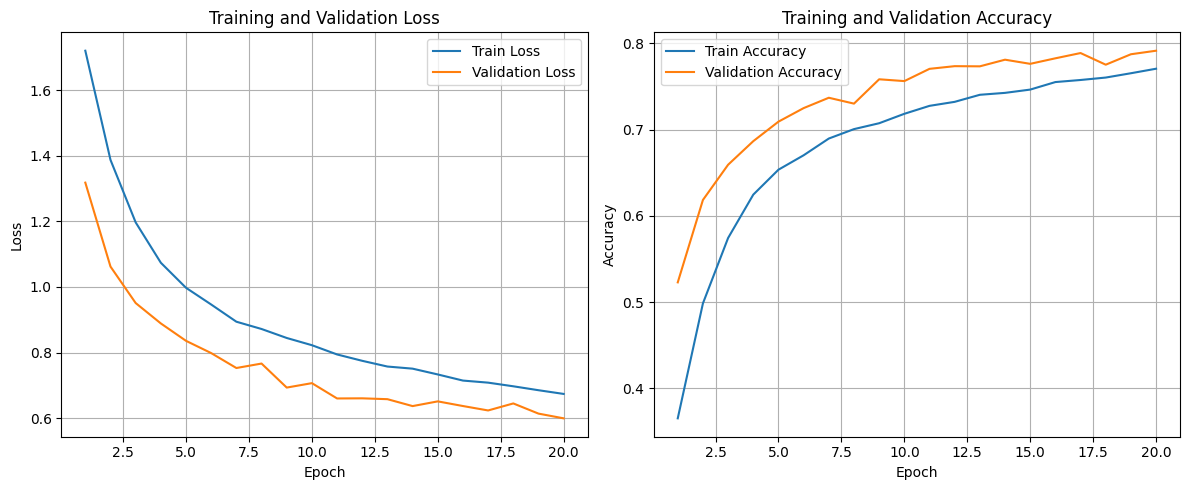

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_05_cifar10.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.7913

Model Evaluation
----------------
Overall accuracy: 0.7913

Per-class accuracy:
  airplane: 0.838
automobile: 0.919
      bird: 0.572
       cat: 0.618
      deer: 0.783
       dog: 0.749
      frog: 0.879
     horse: 0.761
      ship: 0.895
     truck: 0.899

Classification report:
              precision    recall  f1-score   support

    airplane      0.760     0.838     0.797      1000
  automobile      0.895     0.919     0.907      1000
        bird      0.809     0.572     0.670      1000
         cat      0.645     0.618     0.631      1000
        deer      0.775     0.783     0.779      1000
         dog      0.688     0.749     0.717      1000
        frog      0.783     0.879     0.828      1000
       horse      0.872     0.761     0.813      1000
        ship      0.875     0.895     0.885      100

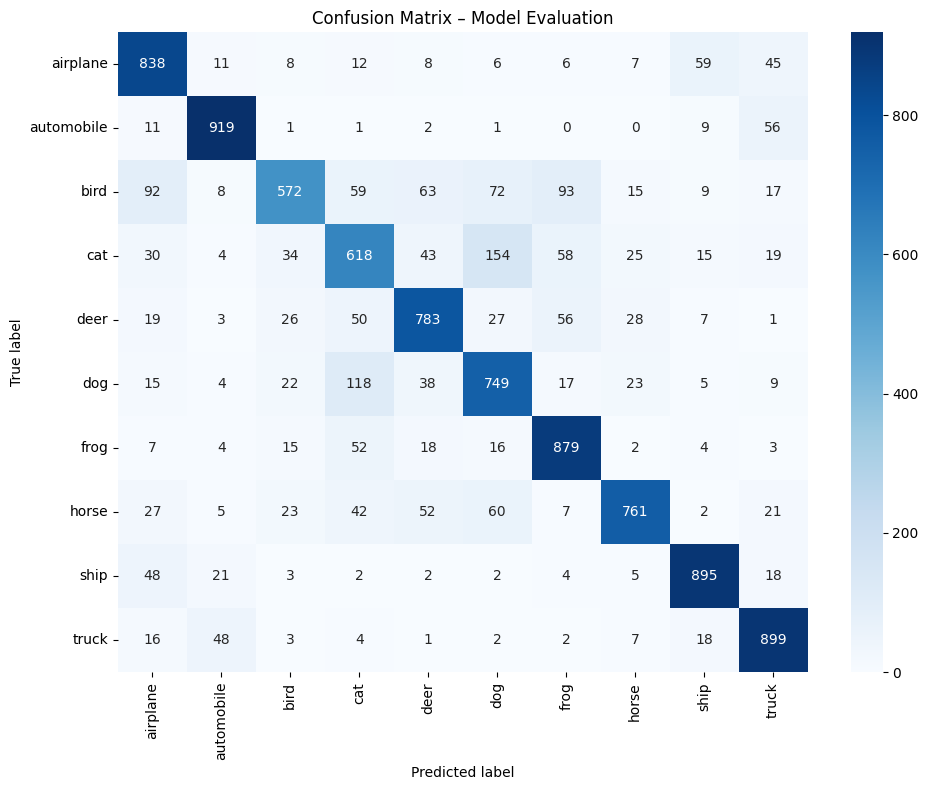

Training model: SimpleCNN_dropout_04
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/20


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.7114 | Train Acc: 0.3709
Train Time: 37.35s
Val   Loss: 1.3096 | Val   Acc: 0.5149
Val   Time: 4.34s

Epoch 2/20


Train Loss: 1.3441 | Train Acc: 0.5118
Train Time: 37.42s
Val   Loss: 1.1337 | Val   Acc: 0.5958
Val   Time: 4.35s

Epoch 3/20


Train Loss: 1.1723 | Train Acc: 0.5835
Train Time: 38.13s
Val   Loss: 0.9644 | Val   Acc: 0.6590
Val   Time: 4.65s

Epoch 4/20


...

Train Loss: 0.6916 | Train Acc: 0.7614
Train Time: 35.72s
Val   Loss: 0.6187 | Val   Acc: 0.7845
Val   Time: 3.78s

Epoch 17/20


Train Loss: 0.6863 | Train Acc: 0.7642
Train Time: 35.52s
Val   Loss: 0.6168 | Val   Acc: 0.7912
Val   Time: 3.75s

Epoch 18/20


Train Loss: 0.6677 | Train Acc: 0.7704
Train Time: 35.66s
Val   Loss: 0.6048 | Val   Acc: 0.7946
Val   Time: 3.88s

Epoch 19/20


Train Loss: 0.6597 | Train Acc: 0.7726
Train Time: 35.68s
Val   Loss: 0.5998 | Val   Acc: 0.7937
Val   Time: 3.70s

Epoch 20/20


Train Loss: 0.6517 | Train Acc: 0.7749
Train Time: 35.14s
Val   Loss: 0.6047 | Val   Acc: 0.7977
Val   Time: 3.78s

Total Training Time  : 743.74s
Total Validation Time: 82.23s


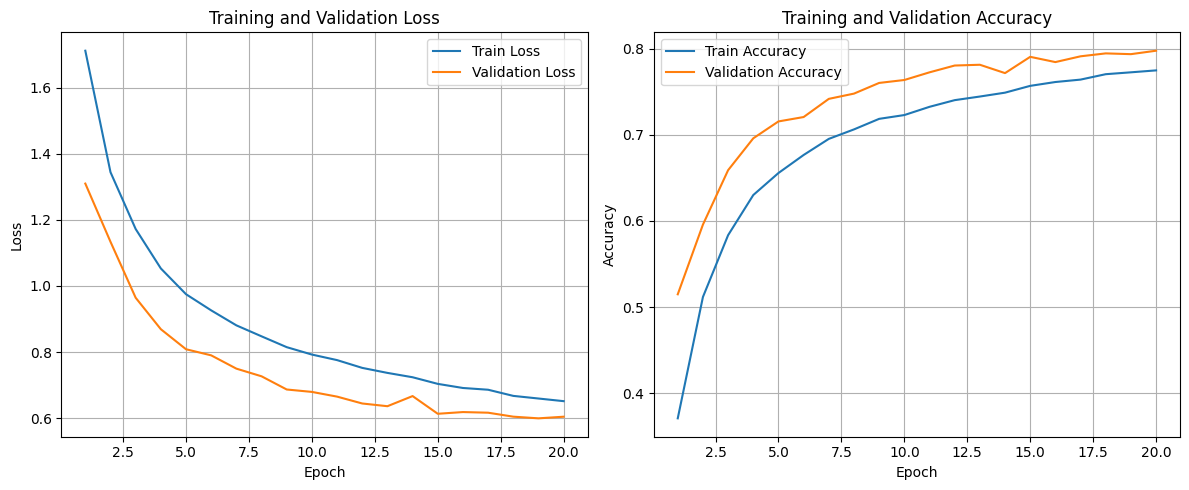

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_04_cifar10.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.7977

Model Evaluation
----------------
Overall accuracy: 0.7977

Per-class accuracy:
  airplane: 0.852
automobile: 0.922
      bird: 0.733
       cat: 0.629
      deer: 0.746
       dog: 0.752
      frog: 0.756
     horse: 0.806
      ship: 0.872
     truck: 0.909

Classification report:
              precision    recall  f1-score   support

    airplane      0.798     0.852     0.824      1000
  automobile      0.918     0.922     0.920      1000
        bird      0.725     0.733     0.729      1000
         cat      0.636     0.629     0.632      1000
        deer      0.786     0.746     0.766      1000
         dog      0.657     0.752     0.701      1000
        frog      0.914     0.756     0.828      1000
       horse      0.834     0.806     0.820      1000
        ship      0.914     0.872     0.893      100

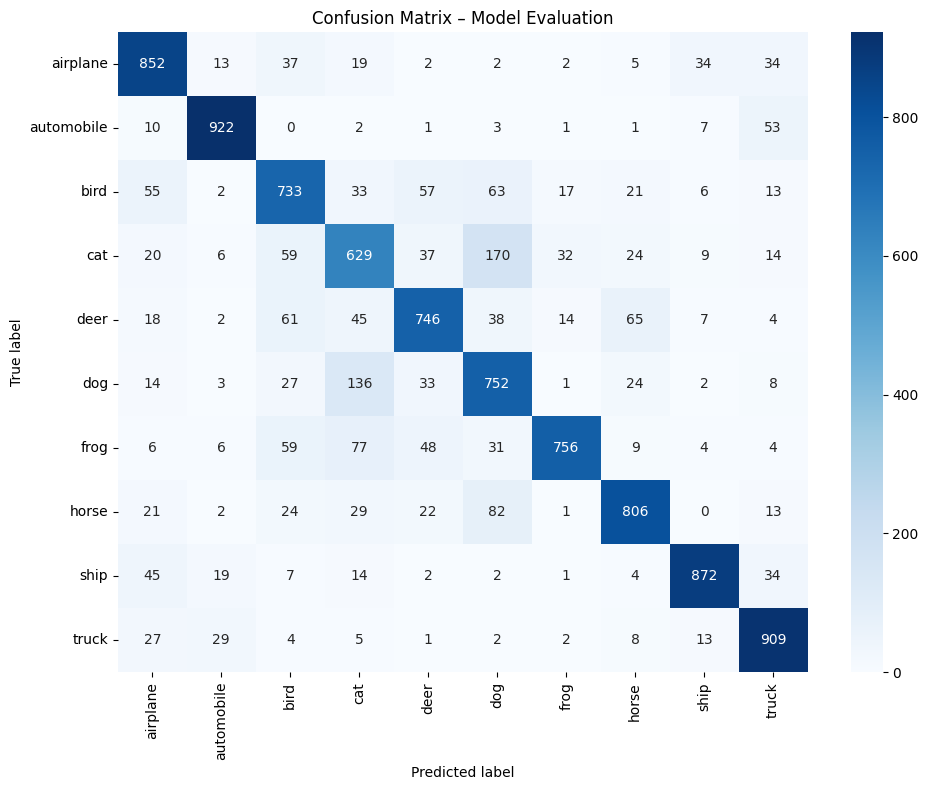

Training model: SimpleCNN_dropout_03
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/20


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.6861 | Train Acc: 0.3794
Train Time: 35.51s
Val   Loss: 1.2801 | Val   Acc: 0.5386
Val   Time: 3.87s

Epoch 2/20


Train Loss: 1.3282 | Train Acc: 0.5216
Train Time: 35.23s
Val   Loss: 1.0714 | Val   Acc: 0.6207
Val   Time: 3.73s

Epoch 3/20


Train Loss: 1.1460 | Train Acc: 0.5902
Train Time: 34.94s
Val   Loss: 0.9470 | Val   Acc: 0.6687
Val   Time: 3.95s

Epoch 4/20


...

Train Loss: 0.6691 | Train Acc: 0.7673
Train Time: 40.68s
Val   Loss: 0.6211 | Val   Acc: 0.7864
Val   Time: 4.17s

Epoch 17/20


Train Loss: 0.6565 | Train Acc: 0.7723
Train Time: 36.09s
Val   Loss: 0.6396 | Val   Acc: 0.7807
Val   Time: 4.02s

Epoch 18/20


Train Loss: 0.6527 | Train Acc: 0.7741
Train Time: 35.82s
Val   Loss: 0.5973 | Val   Acc: 0.7965
Val   Time: 3.87s

Epoch 19/20


Train Loss: 0.6354 | Train Acc: 0.7809
Train Time: 35.84s
Val   Loss: 0.5975 | Val   Acc: 0.7952
Val   Time: 3.73s

Epoch 20/20


Train Loss: 0.6305 | Train Acc: 0.7819
Train Time: 35.53s
Val   Loss: 0.5990 | Val   Acc: 0.7938
Val   Time: 3.82s

Total Training Time  : 716.00s
Total Validation Time: 78.37s


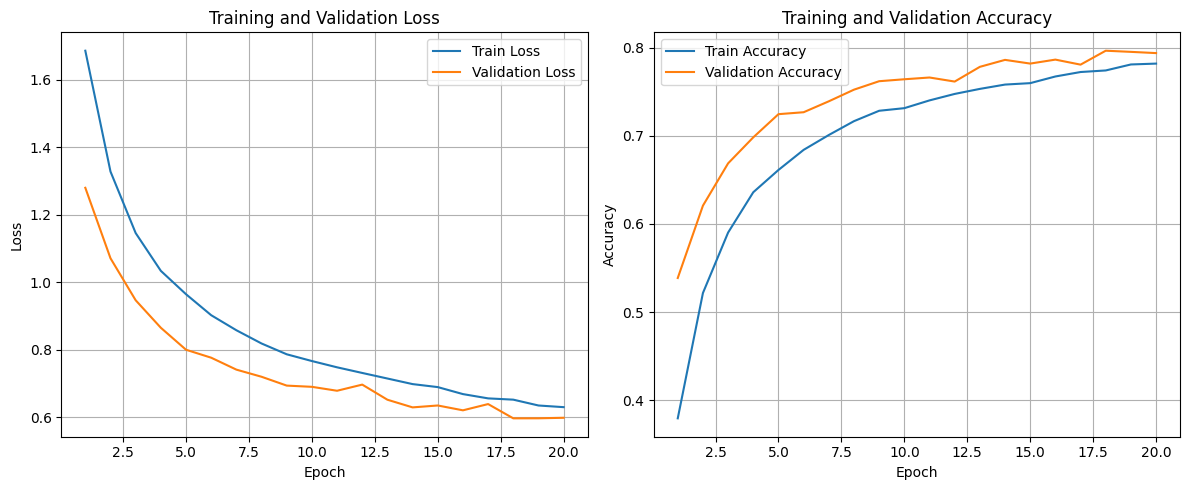

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_03_cifar10.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.7938

Model Evaluation
----------------
Overall accuracy: 0.7938

Per-class accuracy:
  airplane: 0.853
automobile: 0.885
      bird: 0.578
       cat: 0.595
      deer: 0.792
       dog: 0.790
      frog: 0.854
     horse: 0.821
      ship: 0.885
     truck: 0.885

Classification report:
              precision    recall  f1-score   support

    airplane      0.780     0.853     0.815      1000
  automobile      0.925     0.885     0.904      1000
        bird      0.822     0.578     0.679      1000
         cat      0.639     0.595     0.616      1000
        deer      0.768     0.792     0.780      1000
         dog      0.649     0.790     0.713      1000
        frog      0.809     0.854     0.831      1000
       horse      0.827     0.821     0.824      1000
        ship      0.900     0.885     0.893      100

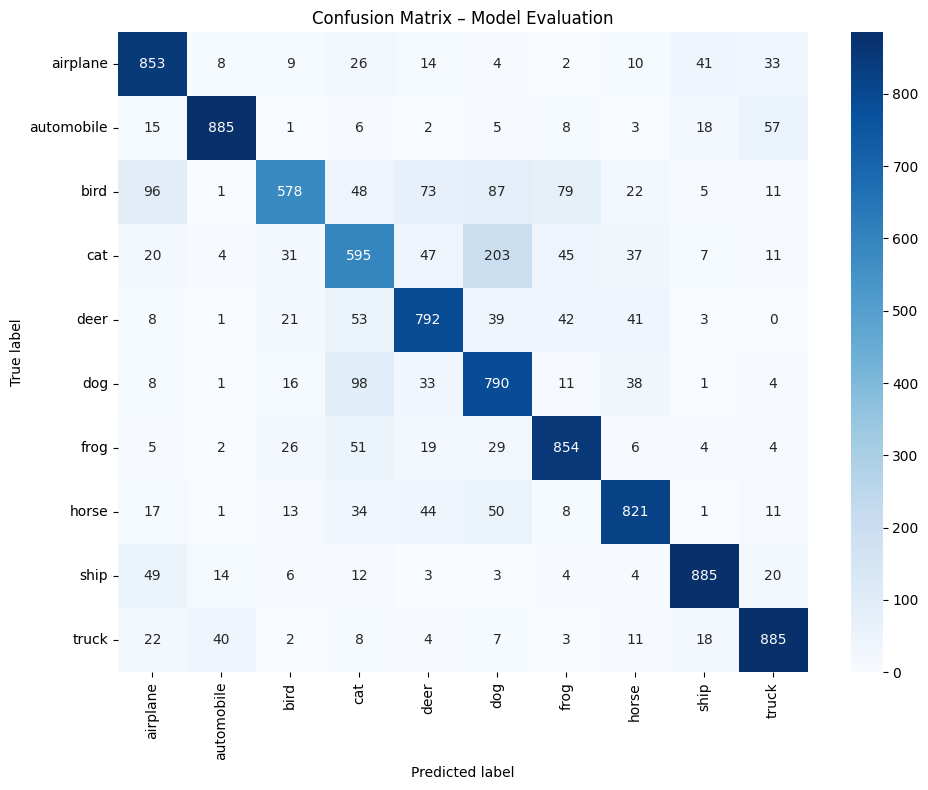

Training model: SimpleCNN_dropout_02
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/20


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.6687 | Train Acc: 0.3896
Train Time: 35.96s
Val   Loss: 1.3478 | Val   Acc: 0.5167
Val   Time: 3.95s

Epoch 2/20


Train Loss: 1.2842 | Train Acc: 0.5387
Train Time: 35.64s
Val   Loss: 1.0298 | Val   Acc: 0.6318
Val   Time: 3.81s

Epoch 3/20


Train Loss: 1.0977 | Train Acc: 0.6100
Train Time: 35.63s
Val   Loss: 0.9021 | Val   Acc: 0.6810
Val   Time: 3.73s

Epoch 4/20


...

Train Loss: 0.6152 | Train Acc: 0.7852
Train Time: 38.91s
Val   Loss: 0.5975 | Val   Acc: 0.7961
Val   Time: 4.22s

Epoch 17/20


Train Loss: 0.6032 | Train Acc: 0.7915
Train Time: 38.43s
Val   Loss: 0.5791 | Val   Acc: 0.8006
Val   Time: 4.10s

Epoch 18/20


Train Loss: 0.5930 | Train Acc: 0.7937
Train Time: 37.85s
Val   Loss: 0.5785 | Val   Acc: 0.8043
Val   Time: 3.95s

Epoch 19/20


Train Loss: 0.5858 | Train Acc: 0.7967
Train Time: 37.78s
Val   Loss: 0.5675 | Val   Acc: 0.8045
Val   Time: 4.13s

Epoch 20/20


Train Loss: 0.5737 | Train Acc: 0.8014
Train Time: 38.67s
Val   Loss: 0.5902 | Val   Acc: 0.8003
Val   Time: 5.32s

Total Training Time  : 735.72s
Total Validation Time: 80.42s


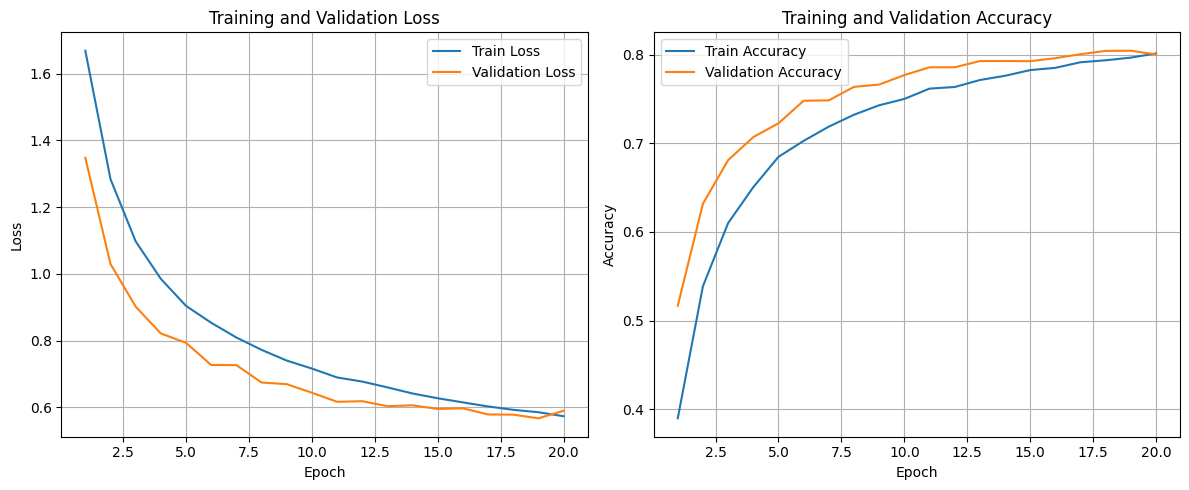

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_02_cifar10.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.8003

Model Evaluation
----------------
Overall accuracy: 0.8003

Per-class accuracy:
  airplane: 0.811
automobile: 0.913
      bird: 0.634
       cat: 0.580
      deer: 0.780
       dog: 0.829
      frog: 0.898
     horse: 0.811
      ship: 0.864
     truck: 0.883

Classification report:
              precision    recall  f1-score   support

    airplane      0.822     0.811     0.816      1000
  automobile      0.903     0.913     0.908      1000
        bird      0.806     0.634     0.710      1000
         cat      0.694     0.580     0.632      1000
        deer      0.782     0.780     0.781      1000
         dog      0.602     0.829     0.698      1000
        frog      0.789     0.898     0.840      1000
       horse      0.881     0.811     0.844      1000
        ship      0.918     0.864     0.890      100

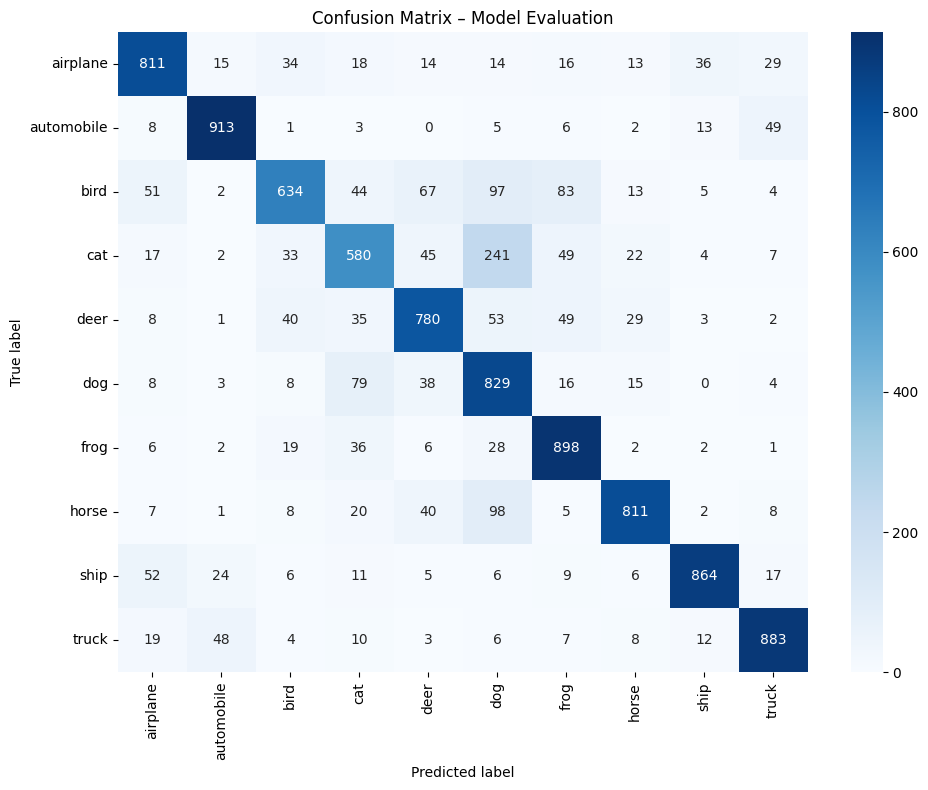

Training model: SimpleCNN_dropout_01
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/20


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.6162 | Train Acc: 0.4086
Train Time: 40.60s
Val   Loss: 1.2275 | Val   Acc: 0.5519
Val   Time: 4.45s

Epoch 2/20


Train Loss: 1.2196 | Train Acc: 0.5629
Train Time: 39.27s
Val   Loss: 1.0103 | Val   Acc: 0.6428
Val   Time: 4.06s

Epoch 3/20


Train Loss: 1.0439 | Train Acc: 0.6323
Train Time: 37.67s
Val   Loss: 0.8871 | Val   Acc: 0.6845
Val   Time: 4.08s

Epoch 4/20


...

Train Loss: 0.5866 | Train Acc: 0.7948
Train Time: 48.69s
Val   Loss: 0.5697 | Val   Acc: 0.8023
Val   Time: 5.96s

Epoch 17/20


Train Loss: 0.5733 | Train Acc: 0.8007
Train Time: 51.64s
Val   Loss: 0.5713 | Val   Acc: 0.8038
Val   Time: 5.95s

Epoch 18/20


Train Loss: 0.5654 | Train Acc: 0.8027
Train Time: 51.35s
Val   Loss: 0.5957 | Val   Acc: 0.7996
Val   Time: 5.62s

Epoch 19/20


Train Loss: 0.5592 | Train Acc: 0.8063
Train Time: 53.05s
Val   Loss: 0.5411 | Val   Acc: 0.8143
Val   Time: 6.69s

Epoch 20/20


Train Loss: 0.5430 | Train Acc: 0.8107
Train Time: 52.50s
Val   Loss: 0.5455 | Val   Acc: 0.8146
Val   Time: 6.34s

Total Training Time  : 879.49s
Total Validation Time: 100.24s


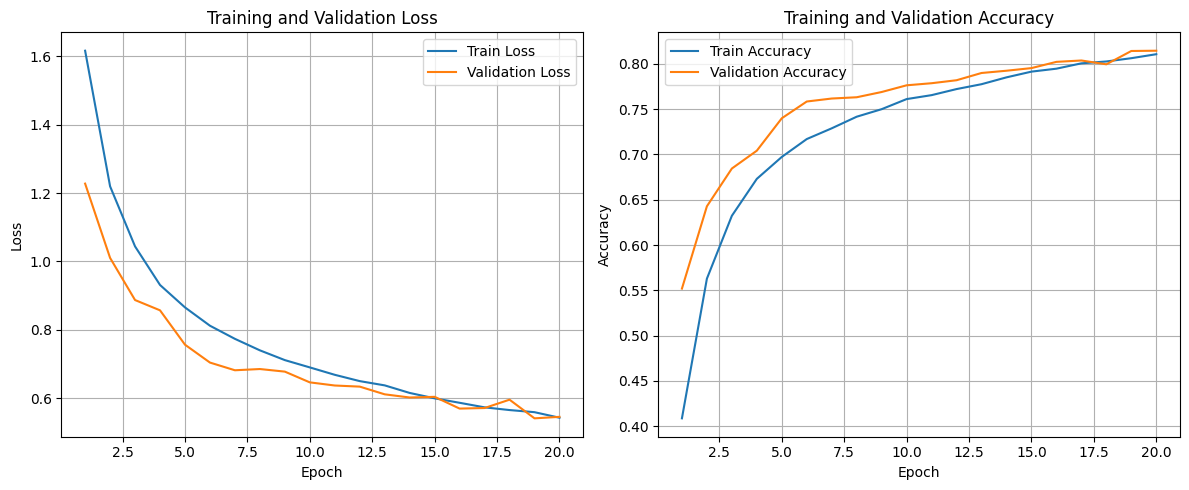

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_01_cifar10.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.8146

Model Evaluation
----------------
Overall accuracy: 0.8146

Per-class accuracy:
  airplane: 0.822
automobile: 0.922
      bird: 0.714
       cat: 0.638
      deer: 0.813
       dog: 0.729
      frog: 0.899
     horse: 0.826
      ship: 0.870
     truck: 0.913

Classification report:
              precision    recall  f1-score   support

    airplane      0.836     0.822     0.829      1000
  automobile      0.921     0.922     0.922      1000
        bird      0.785     0.714     0.748      1000
         cat      0.662     0.638     0.650      1000
        deer      0.766     0.813     0.789      1000
         dog      0.738     0.729     0.733      1000
        frog      0.779     0.899     0.835      1000
       horse      0.883     0.826     0.854      1000
        ship      0.916     0.870     0.892      100

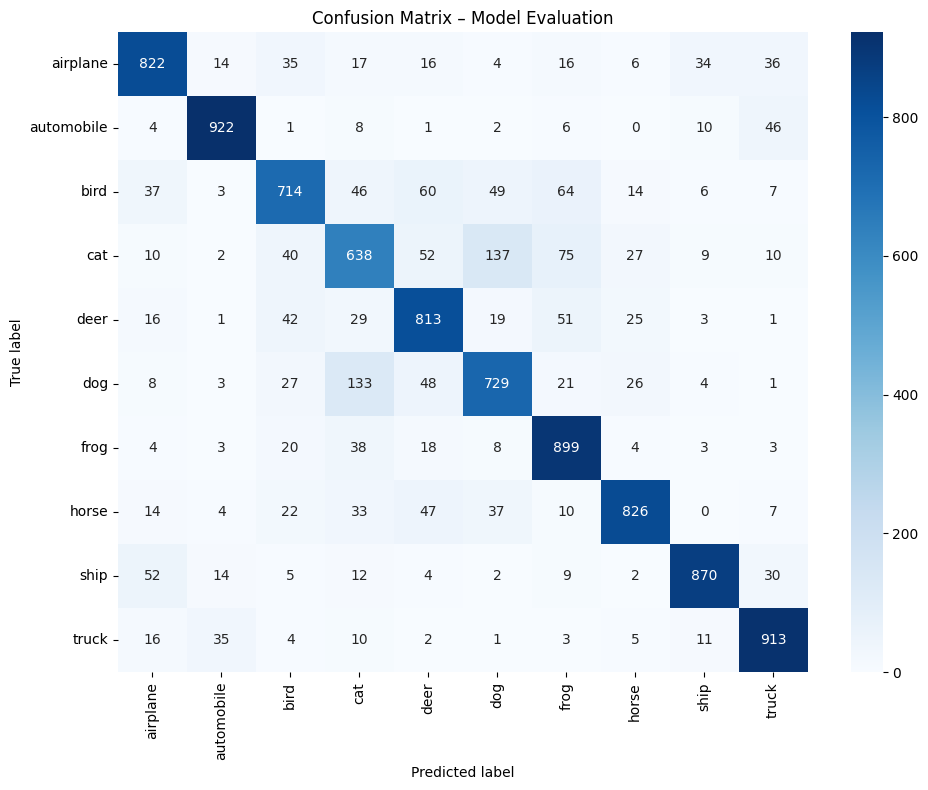

Training model: SimpleCNN_dropout_00
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Starting training...

Epoch 1/20


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/MachineLearningWS25/ML_TU_WS25/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.6277 | Train Acc: 0.4033
Train Time: 55.87s
Val   Loss: 1.3056 | Val   Acc: 0.5278
Val   Time: 7.89s

Epoch 2/20


Train Loss: 1.2827 | Train Acc: 0.5425
Train Time: 61.62s
Val   Loss: 1.0660 | Val   Acc: 0.6134
Val   Time: 6.28s

Epoch 3/20


Train Loss: 1.0775 | Train Acc: 0.6177
Train Time: 59.74s
Val   Loss: 0.8900 | Val   Acc: 0.6845
Val   Time: 6.88s

Epoch 4/20


...

Train Loss: 0.5663 | Train Acc: 0.8033
Train Time: 38.56s
Val   Loss: 0.5857 | Val   Acc: 0.7993
Val   Time: 4.36s

Epoch 17/20


Train Loss: 0.5575 | Train Acc: 0.8066
Train Time: 38.92s
Val   Loss: 0.5801 | Val   Acc: 0.8036
Val   Time: 4.03s

Epoch 18/20


Train Loss: 0.5438 | Train Acc: 0.8105
Train Time: 36.91s
Val   Loss: 0.5856 | Val   Acc: 0.7995
Val   Time: 4.02s

Epoch 19/20


Train Loss: 0.5362 | Train Acc: 0.8144
Train Time: 35.70s
Val   Loss: 0.5701 | Val   Acc: 0.8091
Val   Time: 3.74s

Epoch 20/20


Train Loss: 0.5172 | Train Acc: 0.8196
Train Time: 34.63s
Val   Loss: 0.5929 | Val   Acc: 0.8002
Val   Time: 3.54s

Total Training Time  : 893.26s
Total Validation Time: 100.07s


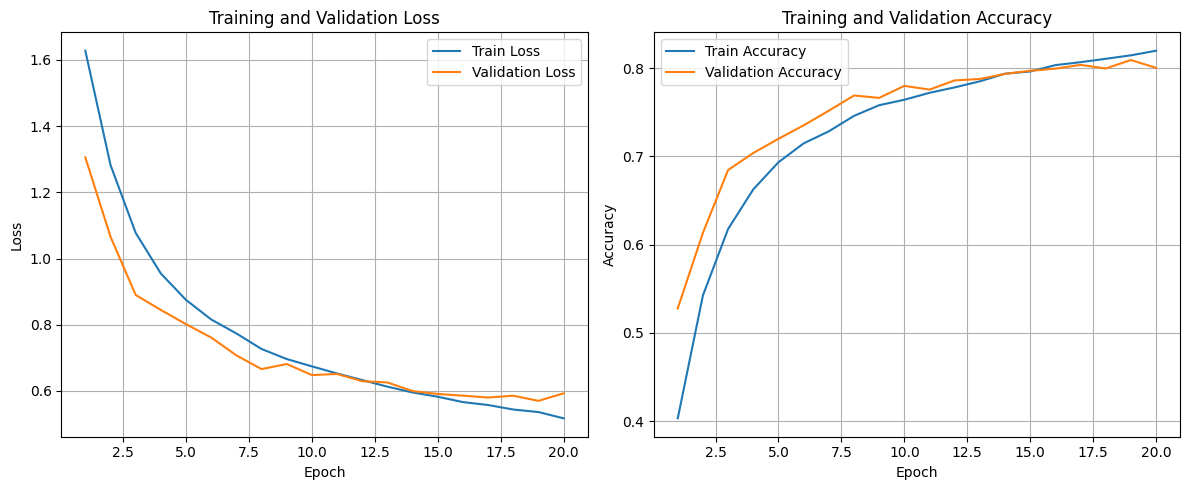

Training completed.
Saved trained model to: cnn_trained_models/simplecnn_dropout_00_cifar10.pth
Evaluating trained model on validation set...
Final validation accuracy: 0.8002

Model Evaluation
----------------
Overall accuracy: 0.8002

Per-class accuracy:
  airplane: 0.800
automobile: 0.895
      bird: 0.587
       cat: 0.705
      deer: 0.739
       dog: 0.731
      frog: 0.885
     horse: 0.847
      ship: 0.906
     truck: 0.907

Classification report:
              precision    recall  f1-score   support

    airplane      0.862     0.800     0.830      1000
  automobile      0.919     0.895     0.907      1000
        bird      0.862     0.587     0.698      1000
         cat      0.575     0.705     0.633      1000
        deer      0.800     0.739     0.768      1000
         dog      0.700     0.731     0.715      1000
        frog      0.804     0.885     0.842      1000
       horse      0.846     0.847     0.847      1000
        ship      0.874     0.906     0.890      100

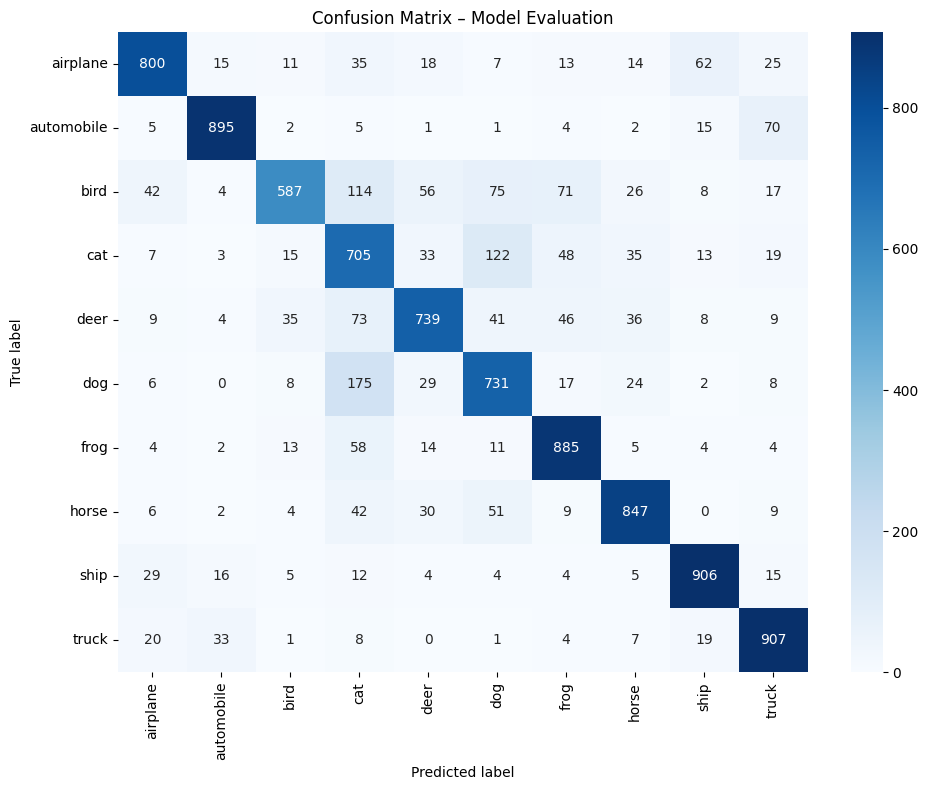

In [2]:
in_channels = 3
num_classes = 10
input_size = 32
base_channels = 32
channel_multiplier = 2
epochs=20

model_selection = {"SimpleCNN_dropout_05": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                input_size=input_size,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.5), 
                    "SimpleCNN_dropout_04": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.4),
                    "SimpleCNN_dropout_03": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.3), 
                    "SimpleCNN_dropout_02": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.2), 
                    "SimpleCNN_dropout_01": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.1),   
                    "SimpleCNN_dropout_00": SimpleCNN(
                                in_channels=in_channels,
                                num_classes=num_classes,
                                base_channels=base_channels,
                                channel_multiplier=channel_multiplier,
                                dropout_rate=0.0)       
                                }

for model_name, model in model_selection.items():
    print(f"Training model: {model_name}")
    # Set the model to the device (GPU/CPU)
    model = model.to(device)
    print(model)

    # Prepare Loss function and optimizer
    criterion = nn.CrossEntropyLoss() # loss function cross entropy that will be used for calculating the loss during training so that the optimizer can update the weights accordingly (remember backpropagation!)

    optimizer = optim.Adam(
        model.parameters(),
        lr=1e-3
    )

    print("Starting training...")
    # Train the model
    trained_model = train_model(
        model=model,
        trainloader=trainloader,
        valloader=valloader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        epochs=epochs
        )
    print("Training completed.")    

    # Save the trained model and check for exisiting files/dirs 
    Path("cnn_trained_models").mkdir(exist_ok=True)
    file_name = f"cnn_trained_models/{model_name.lower()}_cifar10.pth"
    
    # Check if file exists and append version number
    base_path = Path(file_name)
    if base_path.exists():
        version = 1
        while (base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}").exists():
            version += 1
        file_name = str(base_path.parent / f"{base_path.stem}_v{version}{base_path.suffix}")

    torch.save(trained_model.state_dict(), file_name)
    print("Saved trained model to:", file_name)
    
    print("Evaluating trained model on validation set...")
    trained_model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = trained_model(images)
            _, preds = outputs.max(1)

            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

    print(f"Final validation accuracy: {correct / total:.4f}")

    evaluate_model(trained_model, valloader, device=device, class_names=class_names)

    del trained_model

### Show here the training and validation times of our models 
Dropout at 0.5, only things changed is augmentation on/off and the comparison between the two CNN models over number of Epochs

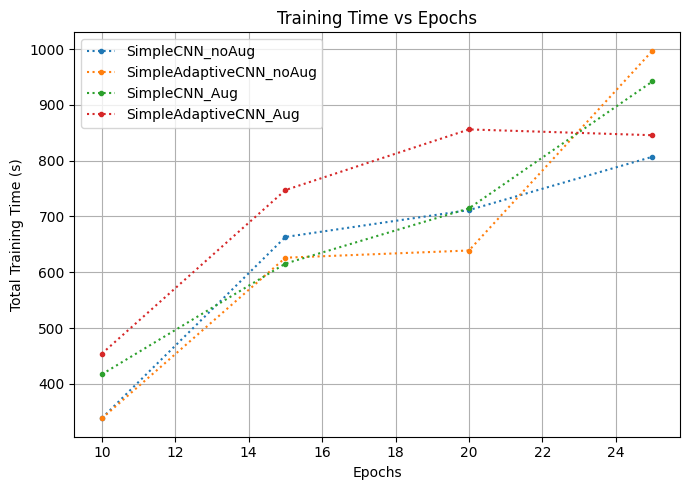

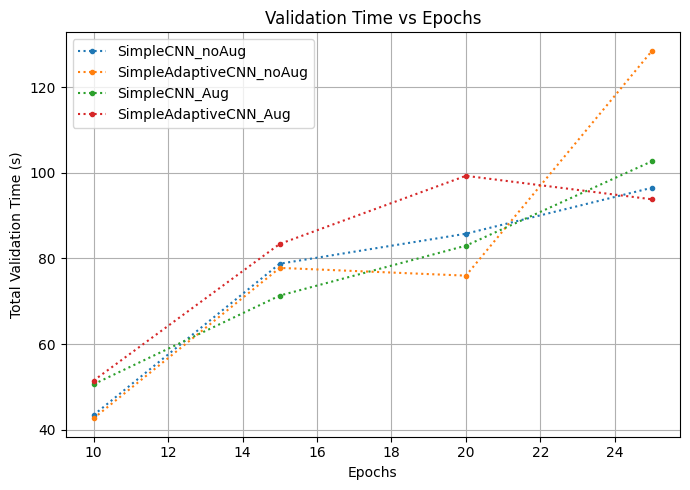

In [32]:
import matplotlib.pyplot as plt

train_val_times = {   
    #/cnn_trained_models/Ten_epochs and /cnn_training_curves/Ten_epochs
    "SimpleCNN_10Epochs_noAug": {
        "Total Training Time": 338.53 ,
        "Total Validation Time": 43.4 
        } ,
    "SimpleAdaptiveCNN_10Epochs_noAug":{
        "Total Training Time"  : 338.12 ,
        "Total Validation Time": 42.64
        },
    "SimpleCNN_10Epochs_Aug": {
        "Total Training Time"  : 417.16,
        "Total Validation Time": 50.60
        },
    "SimpleAdaptiveCNN_10Epochs_Aug" : {
        "Total Training Time" : 454.24,
        "Total Validation Time": 51.46,
        },

    # /cnn_trained_models/Fifteen_epochs and /cnn_training_curves/Fifteen_epochs
    "SimpleCNN_15Epochs_noAug": {
        "Total Training Time"  : 663.27,
        "Total Validation Time": 78.77
        },
    "SimpleAdaptiveCNN_15Epochs_noAug": {
        "Total Training Time"  : 626.09,
        "Total Validation Time": 77.79
        },
    "SimpleCNN_15Epochs_Aug": {
        "Total Training Time"  : 615.57,
        "Total Validation Time": 71.32
        },
    "SimpleAdaptiveCNN_15Epochs_Aug": {
        "Total Training Time"  : 747.35,
        "Total Validation Time": 83.39
        },

    # /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twenty_epochs
    "SimpleCNN_20Epochs_noAug": {
        "Total Training Time"  : 711.45,
        "Total Validation Time": 85.77
        },
    "SimpleAdaptiveCNN_20Epochs_noAug": {
        "Total Training Time"  : 638.99,
        "Total Validation Time": 75.98
        },

    "SimpleCNN_20Epochs_Aug": {
        "Total Training Time"  : 714.55,
        "Total Validation Time": 82.98
        },
    "SimpleAdaptiveCNN_20Epochs_Aug": {
        "Total Training Time"  : 856.05,
        "Total Validation Time": 99.3
        },

    # /cnn_trained_models/Twenty_epochs and /cnn_training_curves/Twentyfive_epochs
    "SimpleCNN_25Epochs_noAug":{
        "Total Training Time"  : 807.0,
        "Total Validation Time": 96.52
    },
    "SimpleAdaptiveCNN_25Epochs_noAug": {
        "Total Training Time"  : 997.14,
        "Total Validation Time": 128.53
    },

    "SimpleCNN_25Epochs_Aug": {
        "Total Training Time"  : 942.12,
        "Total Validation Time": 102.72
        },

    "SimpleAdaptiveCNN_25Epochs_Aug": {
        "Total Training Time"  : 845.66,
        "Total Validation Time": 93.81
        }
}


# Epochs
epochs = [10, 15, 20, 25]

# Extracted data in order of epochs above
train_times = {
    "SimpleCNN_noAug": [338.53, 663.27, 711.45, 807.0],
    "SimpleAdaptiveCNN_noAug": [338.12, 626.09, 638.99, 997.14],
    "SimpleCNN_Aug": [417.16, 615.57, 714.55, 942.12],
    "SimpleAdaptiveCNN_Aug": [454.24, 747.35, 856.05, 845.66],
}

val_times = {
    "SimpleCNN_noAug": [43.4, 78.77, 85.77, 96.52],
    "SimpleAdaptiveCNN_noAug": [42.64, 77.79, 75.98, 128.53],
    "SimpleCNN_Aug": [50.60, 71.32, 82.98, 102.72],
    "SimpleAdaptiveCNN_Aug": [51.46, 83.39, 99.3, 93.81],
}

# Training time plot
plt.figure(figsize=(7, 5))
for label, values in train_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Training Time (s)")
plt.title("Training Time vs Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Validation time plot
plt.figure(figsize=(7, 5))
for label, values in val_times.items():
    plt.plot(epochs, values, marker=".", label=label, linestyle=":")

plt.xlabel("Epochs")
plt.ylabel("Total Validation Time (s)")
plt.title("Validation Time vs Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Plotting here the impact of dropout

Dropout tested: [0.5, 0.4, 0.3, 0.2, 0.1, 0.0]. Other "variables" set: Augmentation on and 20 Epochs

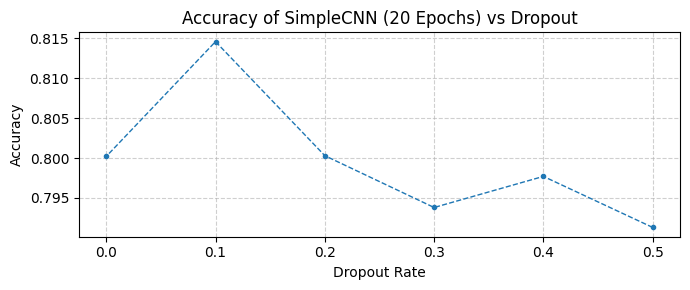

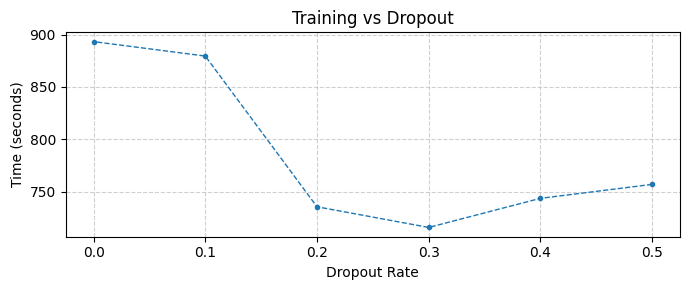

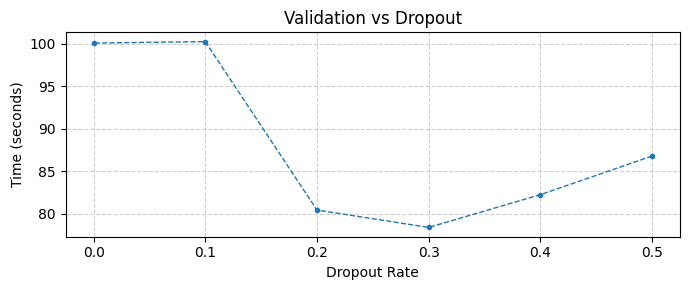

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dropout_model_accuracy = {
    "SimpleCNN_dropout_05": 0.7913, 
    "SimpleCNN_dropout_04": 0.7977, 
    "SimpleCNN_dropout_03": 0.7938,       
    "SimpleCNN_dropout_02": 0.8003,
    "SimpleCNN_dropout_01": 0.8146,   
    "SimpleCNN_dropout_00": 0.8002
    }

# (train, val)        
dropout_model_training_validation_time = {               
    "SimpleCNN_dropout_05": (757.07, 86.77), 
    "SimpleCNN_dropout_04": (743.74, 82.23), 
    "SimpleCNN_dropout_03": (716.00, 78.37),       
    "SimpleCNN_dropout_02": (735.72, 80.42),  
    "SimpleCNN_dropout_01": (879.49, 100.24),
    "SimpleCNN_dropout_00": (893.26, 100.07)
    }


# Extract dropout values from the name
dropout_values = np.array([int(k[-2:]) / 10 for k in dropout_model_accuracy.keys()])
accuracies = np.array(list(dropout_model_accuracy.values()))

# Accuracy Plot
plt.figure(figsize=(7, 3))
plt.plot(dropout_values, accuracies, marker=".", linestyle="--", linewidth=1)

plt.xlabel("Dropout Rate")
plt.ylabel("Accuracy")
plt.title("Accuracy of SimpleCNN (20 Epochs) vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

# Training & Validation Time Plot
train_times = [v[0] for v in dropout_model_training_validation_time.values()]
val_times = [v[1] for v in dropout_model_training_validation_time.values()]

plt.figure(figsize=(7, 3))
plt.plot(dropout_values, train_times, marker=".", linestyle="--", linewidth=1, label="Training Time")

plt.xlabel("Dropout Rate")
plt.ylabel("Time (seconds)")
plt.title("Training vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(dropout_values, val_times, marker=".", linestyle="--", linewidth=1, label="Validation Time")

plt.xlabel("Dropout Rate")
plt.ylabel("Time (seconds)")
plt.title("Validation vs Dropout")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(dropout_values)
plt.tight_layout()
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Class names from the dataset
classes = train_dataset.classes

def unnormalize(img_tensor):
    # Convert normalized tensor back to image for display
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

def show_augmented_vs_original(transform, dataset, num_images=8):
    # Get original images (PIL) from dataset
    original_images = [dataset[i][0] for i in range(num_images)]

    # Apply augmentations
    augmented_images = [transform(img) for img in original_images]

    fig, axs = plt.subplots(2, num_images, figsize=(16, 4))
    fig.suptitle('Original Images (Top) vs. Augmented Images (Bottom)', fontsize=16)

    for i in range(num_images):
        # Display original images
        axs[0, i].imshow(original_images[i])
        axs[0, i].axis('off')
        if i == 0:
            axs[0, i].set_ylabel('Original', fontsize=12)

        # Display augmented images (unnormalized tensor)
        img = unnormalize(augmented_images[i])
        axs[1, i].imshow(img)
        axs[1, i].axis('off')
        if i == 0:
            axs[1, i].set_ylabel('Augmented', fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# To use this function, pass your transform pipeline and the raw dataset without transforms:
show_augmented_vs_original(transform=train_transforms, dataset=raw_dataset)

### Old testing area


In [ ]:
trained_model = train_model(
    model=model,
    trainloader=trainloader,
    valloader=valloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=10
)


Epoch 1/10


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
Training: 100%|██████████| 391/391 [00:33<00:00, 12.43it/s]

In [ ]:
# save the trained model
file_name = "cnn_trained_models/simple_cnn_cifar10_v2.pth"
torch.save(trained_model.state_dict(), file_name)
#del trained_model

In [8]:
# load the saved model with the same parameters initially set
trained_model = SimpleCNN(in_channels=3, num_classes=10, input_size=32, base_channels=32, channel_multiplier=2)
trained_model.load_state_dict(torch.load(file_name))

<All keys matched successfully>

In [9]:
trained_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in valloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        _, preds = outputs.max(1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

print(f"Final validation accuracy: {correct / total:.4f}")


Final validation accuracy: 0.7299


In [10]:
from analysis.evaluation import evaluate_model

/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Model Evaluation
----------------
Overall accuracy: 0.7299

Per-class accuracy:
  airplane: 0.861
automobile: 0.890
      bird: 0.627
       cat: 0.534
      deer: 0.649
       dog: 0.521
      frog: 0.822
     horse: 0.799
      ship: 0.852
     truck: 0.744

Classification report:
              precision    recall  f1-score   support

    airplane      0.643     0.861     0.736      1000
  automobile      0.807     0.890     0.846      1000
        bird      0.637     0.627     0.632      1000
         cat      0.554     0.534     0.544      1000
        deer      0.720     0.649     0.682      1000
         dog      0.719     0.521     0.604      1000
        frog      0.800     0.822     0.811      1000
       horse      0.757     0.799     0.778      1000
        ship      0.824     0.852     0.838      1000
       truck      0.859     0.744     0.797      1000

    accuracy                          0.730     10000
   macro avg      0.732     0.730     0.727     10000
weighted av

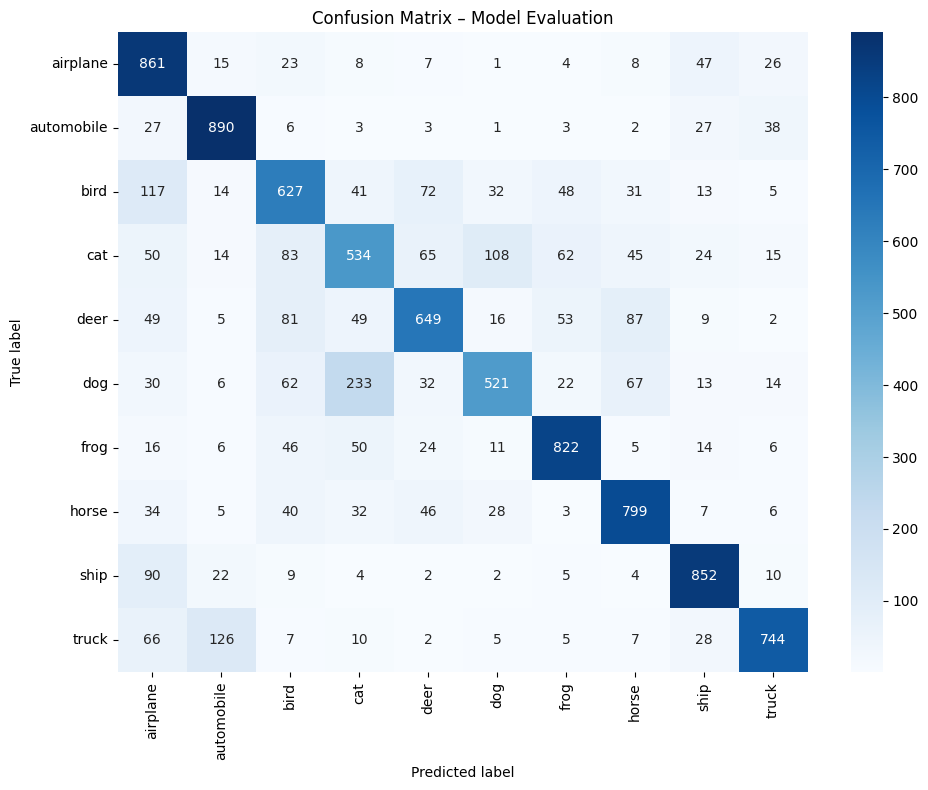

{'overall_accuracy': 0.7299000024795532,
 'per_class_accuracy': array([0.861, 0.89 , 0.627, 0.534, 0.649, 0.521, 0.822, 0.799, 0.852,
        0.744]),
 'confusion_matrix': array([[861,  15,  23,   8,   7,   1,   4,   8,  47,  26],
        [ 27, 890,   6,   3,   3,   1,   3,   2,  27,  38],
        [117,  14, 627,  41,  72,  32,  48,  31,  13,   5],
        [ 50,  14,  83, 534,  65, 108,  62,  45,  24,  15],
        [ 49,   5,  81,  49, 649,  16,  53,  87,   9,   2],
        [ 30,   6,  62, 233,  32, 521,  22,  67,  13,  14],
        [ 16,   6,  46,  50,  24,  11, 822,   5,  14,   6],
        [ 34,   5,  40,  32,  46,  28,   3, 799,   7,   6],
        [ 90,  22,   9,   4,   2,   2,   5,   4, 852,  10],
        [ 66, 126,   7,  10,   2,   5,   5,   7,  28, 744]]),
 'predictions': tensor([3, 8, 8,  ..., 5, 4, 7]),
 'labels': tensor([3, 8, 8,  ..., 5, 1, 7])}

In [11]:
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]
evaluate_model(trained_model, valloader, device="cpu", class_names=class_names)

In [21]:
# target output size of 5x7
m = nn.AdaptiveAvgPool2d((5, 7))
input = torch.randn(1, 64, 8, 9)
output = m(input)
print(output.shape)

# target output size of 7x7 (square)
m = nn.AdaptiveAvgPool2d(7)
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of 10x7
m = nn.AdaptiveAvgPool2d((None, 7))
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of 15x15
m = nn.AdaptiveAvgPool2d((15, 15))
input = torch.randn(1, 64, 10, 9)
output = m(input)
print(output.shape)

# target output size of the same size
m = nn.AdaptiveAvgPool2d((2,2))
input = torch.randn(1, 6, 2, 2)
output = m(input)
print(output.shape)


torch.Size([1, 64, 5, 7])
torch.Size([1, 64, 7, 7])
torch.Size([1, 64, 10, 7])
torch.Size([1, 64, 15, 15])
torch.Size([1, 6, 2, 2])


In [23]:
input , output

(tensor([[[[-0.9263, -0.5816],
           [-1.1925, -0.3591]],
 
          [[ 0.8660, -0.3756],
           [-2.2855,  1.0001]],
 
          [[-1.5795, -0.2661],
           [-0.6010, -1.2038]],
 
          [[ 1.5281,  1.4366],
           [ 1.2875, -1.0313]],
 
          [[-1.2212, -0.4418],
           [-0.2393,  0.5293]],
 
          [[ 0.0678, -0.5407],
           [ 1.0346,  0.4056]]]]),
 tensor([[[[-0.9263, -0.5816],
           [-1.1925, -0.3591]],
 
          [[ 0.8660, -0.3756],
           [-2.2855,  1.0001]],
 
          [[-1.5795, -0.2661],
           [-0.6010, -1.2038]],
 
          [[ 1.5281,  1.4366],
           [ 1.2875, -1.0313]],
 
          [[-1.2212, -0.4418],
           [-0.2393,  0.5293]],
 
          [[ 0.0678, -0.5407],
           [ 1.0346,  0.4056]]]]))